<a href="https://colab.research.google.com/github/Nipun-Khandelwal/Agentic_marksheet/blob/main/MLproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install -q librosa kagglehub imbalanced-learn noisereduce tqdm seaborn shap scikit-learn torch torchvision

In [2]:
import os, warnings, pickle, json, time
import numpy as np
import pandas as pd
import librosa
import librosa.display
import noisereduce as nr
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from tqdm import tqdm
warnings.filterwarnings('ignore')

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torch.optim.lr_scheduler import CosineAnnealingLR

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, auc,
                             accuracy_score, f1_score)
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
import shap

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"✅ Device: {DEVICE}")
print(f"✅ PyTorch version: {torch.__version__}")

✅ Device: cuda
✅ PyTorch version: 2.10.0+cu128


In [3]:
import kagglehub

DATA_PATH = kagglehub.dataset_download("vbookshelf/respiratory-sound-database")
BASE      = os.path.join(DATA_PATH, "Respiratory_Sound_Database", "Respiratory_Sound_Database")
AUDIO_DIR = os.path.join(BASE, "audio_and_txt_files")
DIAG_FILE = os.path.join(BASE, "patient_diagnosis.csv")

wav_files = [f for f in os.listdir(AUDIO_DIR) if f.endswith(".wav")]
print(f"📁 Audio directory: {AUDIO_DIR}")
print(f"🎵 Total .wav files: {len(wav_files)}")

100%|██████████| 3.69G/3.69G [01:35<00:00, 41.5MB/s]

Extracting files...


📁 Audio directory: /root/.cache/kagglehub/datasets/vbookshelf/respiratory-sound-database/versions/2/Respiratory_Sound_Database/Respiratory_Sound_Database/audio_and_txt_files
🎵 Total .wav files: 920


=== ORIGINAL CLASS DISTRIBUTION ===
Diagnosis
COPD              64
Healthy           26
URTI              14
Bronchiectasis     7
Bronchiolitis      6
Pneumonia          6
LRTI               2
Asthma             1
Name: count, dtype: int64

=== REMAPPED CLASS DISTRIBUTION ===
Label
COPD         64
Healthy      26
Other        16
URTI         14
Pneumonia     6
Name: count, dtype: int64


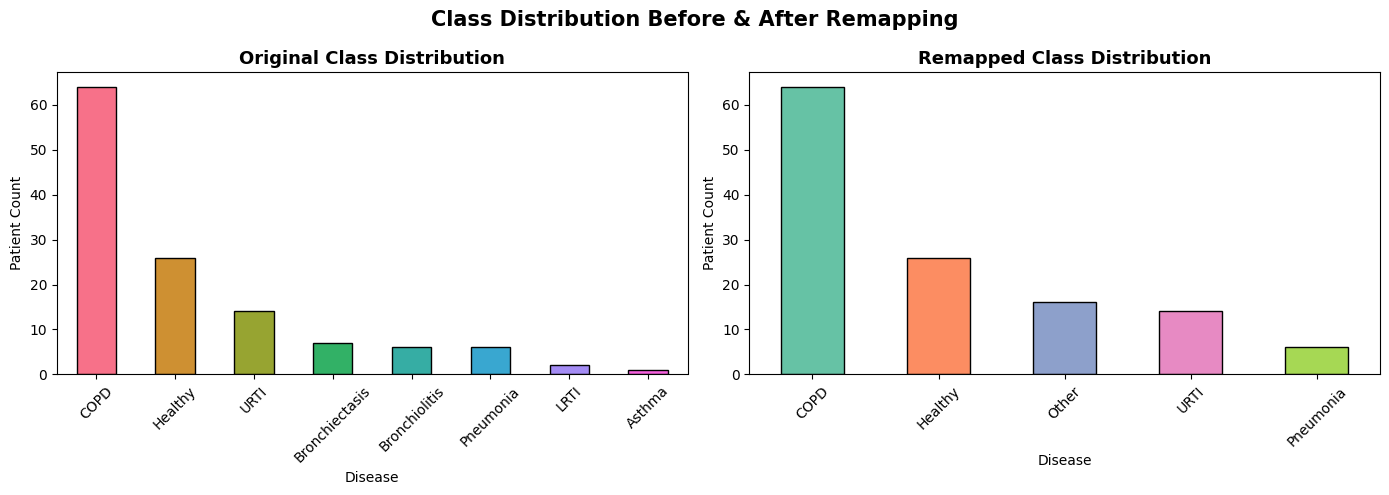

In [4]:
diag_df = pd.read_csv(DIAG_FILE, names=["Patient_ID", "Diagnosis"])

# Original distribution
print("=== ORIGINAL CLASS DISTRIBUTION ===")
print(diag_df["Diagnosis"].value_counts())

REMAP = {
    "COPD":           "COPD",
    "Healthy":        "Healthy",
    "URTI":           "URTI",
    "Pneumonia":      "Pneumonia",
    "Bronchiectasis": "Other",
    "Bronchiolitis":  "Other",
    "LRTI":           "Other",
    "Asthma":         "Other",
}
diag_df["Label"] = diag_df["Diagnosis"].map(REMAP)
pid2label = dict(zip(diag_df.Patient_ID, diag_df.Label))

print("\n=== REMAPPED CLASS DISTRIBUTION ===")
print(diag_df["Label"].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
diag_df["Diagnosis"].value_counts().plot(kind="bar", ax=axes[0],
    color=sns.color_palette("husl", 8), edgecolor="black")
axes[0].set_title("Original Class Distribution", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Disease"); axes[0].set_ylabel("Patient Count")
axes[0].tick_params(axis='x', rotation=45)

diag_df["Label"].value_counts().plot(kind="bar", ax=axes[1],
    color=sns.color_palette("Set2", 5), edgecolor="black")
axes[1].set_title("Remapped Class Distribution", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Disease"); axes[1].set_ylabel("Patient Count")
axes[1].tick_params(axis='x', rotation=45)

plt.suptitle("Class Distribution Before & After Remapping", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

In [5]:
SR         = 22050
DURATION   = 5
N_MFCC     = 40
N_MELS     = 64
HOP_LENGTH = 512
FIXED_LEN  = SR * DURATION


def load_and_clean(path):
    """Load, resample, denoise, and pad/trim audio to fixed length."""
    y, _ = librosa.load(path, sr=SR, duration=DURATION)
    if len(y) < FIXED_LEN:
        y = np.pad(y, (0, FIXED_LEN - len(y)))
    else:
        y = y[:FIXED_LEN]
    noise = y[:int(SR * 0.5)]
    y = nr.reduce_noise(y=y, y_noise=noise, sr=SR, prop_decrease=0.8)
    return y


def extract_features(y):
    """
    Extracts a rich 502-dimensional feature vector:
      - MFCCs + Delta + Delta-Delta  (40 x 3 x 2 = 240 dims)
      - Mel spectrogram stats         (64 x 2     = 128 dims)
      - Chroma STFT                   (12 x 2     =  24 dims)
      - Spectral Contrast             (7  x 2     =  14 dims)
      - Spectral Centroid / Bandwidth (1  x 2 x 2 =   4 dims)
      - Zero Crossing Rate            (1  x 2     =   2 dims)
      - RMS Energy                    (1  x 2     =   2 dims)
    Total: ~414+ dims
    """
    def stats(x):
        return np.concatenate([x.mean(axis=1), x.std(axis=1)])

    # MFCCs and their deltas
    mfcc    = librosa.feature.mfcc(y=y, sr=SR, n_mfcc=N_MFCC, hop_length=HOP_LENGTH)
    d_mfcc  = librosa.feature.delta(mfcc)
    dd_mfcc = librosa.feature.delta(mfcc, order=2)

    # Mel spectrogram
    mel    = librosa.feature.melspectrogram(y=y, sr=SR, n_mels=N_MELS, hop_length=HOP_LENGTH)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # Chroma features (pitch class energy)
    chroma = librosa.feature.chroma_stft(y=y, sr=SR, hop_length=HOP_LENGTH)

    # Spectral Contrast (valley vs peak energy in subbands)
    contrast = librosa.feature.spectral_contrast(y=y, sr=SR, hop_length=HOP_LENGTH)

    # Spectral Centroid (brightness of sound)
    centroid  = librosa.feature.spectral_centroid(y=y, sr=SR, hop_length=HOP_LENGTH)

    # Spectral Bandwidth
    bandwidth = librosa.feature.spectral_bandwidth(y=y, sr=SR, hop_length=HOP_LENGTH)

    # Zero Crossing Rate (how noisy/tonal the signal is)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=HOP_LENGTH)

    # RMS Energy
    rms = librosa.feature.rms(y=y, hop_length=HOP_LENGTH)

    feat = np.concatenate([
        stats(mfcc), stats(d_mfcc), stats(dd_mfcc),
        stats(mel_db), stats(chroma), stats(contrast),
        stats(centroid), stats(bandwidth), stats(zcr), stats(rms)
    ])
    return feat.astype(np.float32)


print(f"✅ Feature vector size: {len(extract_features(np.zeros(FIXED_LEN)))}")

✅ Feature vector size: 414


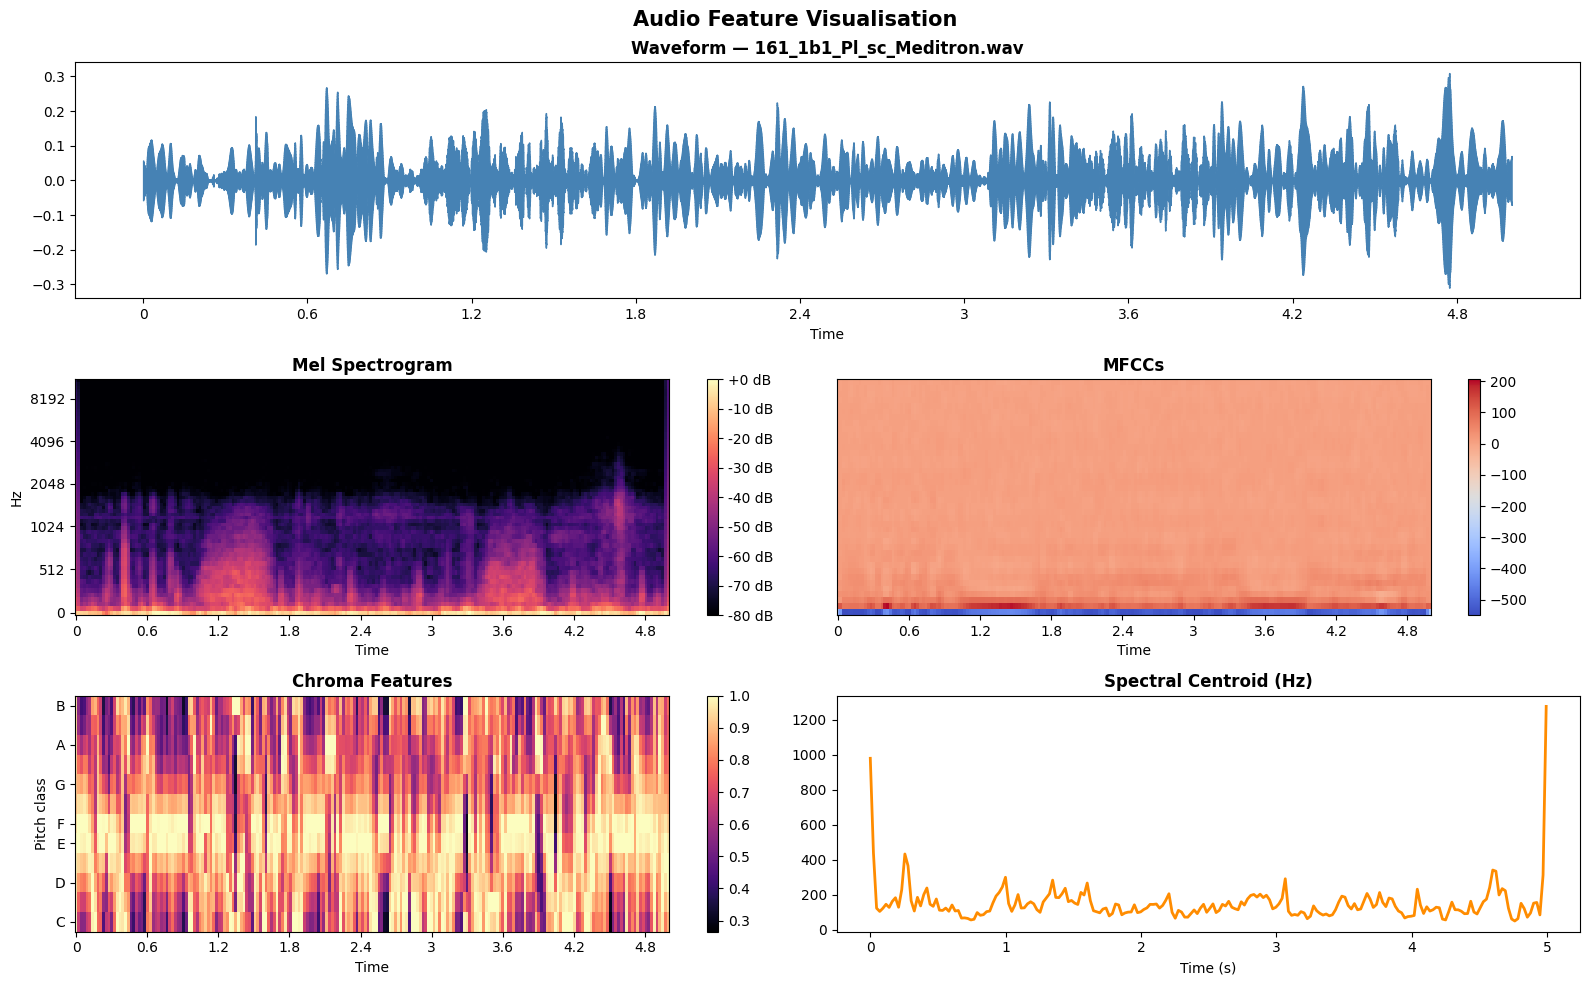

In [6]:
sample_path = os.path.join(AUDIO_DIR, wav_files[0])
y_s, _      = librosa.load(sample_path, sr=SR, duration=DURATION)

fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 2, figure=fig)

# Waveform
ax1 = fig.add_subplot(gs[0, :])
librosa.display.waveshow(y_s, sr=SR, ax=ax1, color="steelblue")
ax1.set_title(f"Waveform — {wav_files[0]}", fontsize=12, fontweight="bold")

# Mel spectrogram
ax2 = fig.add_subplot(gs[1, 0])
mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y_s, sr=SR, n_mels=N_MELS), ref=np.max)
img2 = librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="mel", ax=ax2)
fig.colorbar(img2, ax=ax2, format="%+2.0f dB")
ax2.set_title("Mel Spectrogram", fontsize=12, fontweight="bold")

# MFCCs
ax3 = fig.add_subplot(gs[1, 1])
mfcc_vis = librosa.feature.mfcc(y=y_s, sr=SR, n_mfcc=N_MFCC)
img3 = librosa.display.specshow(mfcc_vis, sr=SR, hop_length=HOP_LENGTH, x_axis="time", ax=ax3)
fig.colorbar(img3, ax=ax3)
ax3.set_title("MFCCs", fontsize=12, fontweight="bold")

# Chroma
ax4 = fig.add_subplot(gs[2, 0])
chroma_vis = librosa.feature.chroma_stft(y=y_s, sr=SR)
img4 = librosa.display.specshow(chroma_vis, sr=SR, hop_length=HOP_LENGTH, x_axis="time", y_axis="chroma", ax=ax4)
fig.colorbar(img4, ax=ax4)
ax4.set_title("Chroma Features", fontsize=12, fontweight="bold")

# Spectral Centroid
ax5 = fig.add_subplot(gs[2, 1])
frames = range(len(librosa.feature.spectral_centroid(y=y_s, sr=SR)[0]))
t = librosa.frames_to_time(frames, sr=SR)
ax5.plot(t, librosa.feature.spectral_centroid(y=y_s, sr=SR)[0], color="darkorange", lw=2)
ax5.set_title("Spectral Centroid (Hz)", fontsize=12, fontweight="bold")
ax5.set_xlabel("Time (s)")

plt.suptitle("Audio Feature Visualisation", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()

In [7]:
X_list, y_list, skipped = [], [], 0

for fname in tqdm(wav_files, desc="Extracting features"):
    pid   = int(fname.split("_")[0])
    label = pid2label.get(pid)
    if label is None:
        skipped += 1
        continue
    try:
        feat = extract_features(load_and_clean(os.path.join(AUDIO_DIR, fname)))
        X_list.append(feat)
        y_list.append(label)
    except Exception as e:
        skipped += 1

X     = np.array(X_list, dtype=np.float32)
y_raw = np.array(y_list)
print(f"\n✅ Feature matrix shape : {X.shape}")
print(f"   Skipped files        : {skipped}")
print(f"\n=== LABEL DISTRIBUTION ===")
print(pd.Series(y_raw).value_counts())

Extracting features: 100%|██████████| 920/920 [02:44<00:00,  5.59it/s]


✅ Feature matrix shape : (920, 414)
   Skipped files        : 0

=== LABEL DISTRIBUTION ===
COPD         793
Pneumonia     37
Healthy       35
Other         32
URTI          23
Name: count, dtype: int64


In [8]:
from sklearn.model_selection import train_test_split

le     = LabelEncoder()
y_enc  = le.fit_transform(y_raw)
print(f"Classes: {le.classes_}")

# Step 1: Split off 15% test — NEVER touched until final evaluation
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y_enc, test_size=0.15, random_state=SEED, stratify=y_enc)

# Step 2: Split remaining 85% into train (82%) and val (18%) → ~70/15 overall
X_train_raw, X_val_raw, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.176, random_state=SEED, stratify=y_temp)

print(f"\n📊 Split sizes:")
print(f"   Train : {len(X_train_raw)} ({len(X_train_raw)/len(X)*100:.1f}%)")
print(f"   Val   : {len(X_val_raw)}   ({len(X_val_raw)/len(X)*100:.1f}%)")
print(f"   Test  : {len(X_test)}   ({len(X_test)/len(X)*100:.1f}%)")

print(f"\n⚠️  Test set locked away — not used until final evaluation")

Classes: ['COPD' 'Healthy' 'Other' 'Pneumonia' 'URTI']

📊 Split sizes:
   Train : 644 (70.0%)
   Val   : 138   (15.0%)
   Test  : 138   (15.0%)

⚠️  Test set locked away — not used until final evaluation


In [9]:
from sklearn.utils.class_weight import compute_class_weight

# Fit scaler on training data ONLY
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_val_sc   = scaler.transform(X_val_raw)
X_test_sc  = scaler.transform(X_test)

# SMOTE only on training data
sm = SMOTE(random_state=SEED, k_neighbors=3)
X_train, y_train_sm = sm.fit_resample(X_train_sc, y_train)

# Compute class weights — penalises the model MORE for misclassifying rare classes
class_weights = compute_class_weight('balanced',
                                      classes=np.unique(y_train_sm),
                                      y=y_train_sm)
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float32).to(DEVICE)

print(f"Before SMOTE — Train: {X_train_sc.shape}")
print(f"After  SMOTE — Train: {X_train.shape}")
print(f"\nClass weights (higher = model penalised more for missing this class):")
for cls, w in zip(le.classes_, class_weights):
    print(f"  {cls:15s} → {w:.4f}")

Before SMOTE — Train: (644, 414)
After  SMOTE — Train: (2775, 414)

Class weights (higher = model penalised more for missing this class):
  COPD            → 1.0000
  Healthy         → 1.0000
  Other           → 1.0000
  Pneumonia       → 1.0000
  URTI            → 1.0000


In [10]:
from sklearn.utils.class_weight import compute_class_weight

print("=" * 50)
print("     TRAINING RANDOM FOREST BASELINE")
print("=" * 50)

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)

t0 = time.time()
rf_model.fit(X_train, y_train_sm)
rf_val_preds  = rf_model.predict(X_val_sc)
rf_val_probs  = rf_model.predict_proba(X_val_sc)
rf_val_acc    = accuracy_score(y_val, rf_val_preds)
rf_val_f1     = f1_score(y_val, rf_val_preds, average="macro")
rf_time       = time.time() - t0

print(f"\nVal Accuracy : {rf_val_acc*100:.2f}%")
print(f"Val F1 Macro : {rf_val_f1:.4f}")
print(f"Time         : {rf_time:.1f}s")
print("\nClassification Report (Validation):")
print(classification_report(y_val, rf_val_preds, target_names=le.classes_))

     TRAINING RANDOM FOREST BASELINE

Val Accuracy : 89.86%
Val F1 Macro : 0.4545
Time         : 8.3s

Classification Report (Validation):
              precision    recall  f1-score   support

        COPD       0.96      0.98      0.97       119
     Healthy       0.44      0.80      0.57         5
       Other       0.50      0.20      0.29         5
   Pneumonia       0.50      0.40      0.44         5
        URTI       0.00      0.00      0.00         4

    accuracy                           0.90       138
   macro avg       0.48      0.48      0.45       138
weighted avg       0.88      0.90      0.88       138



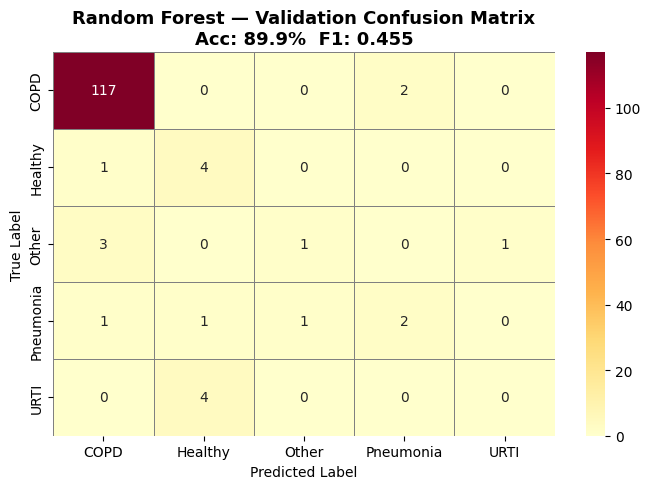

✅ Saved: rf_confusion_matrix.png


In [11]:
cm_rf = confusion_matrix(y_val, rf_val_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="YlOrRd",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor="gray")
plt.title(f"Random Forest — Validation Confusion Matrix\nAcc: {rf_val_acc*100:.1f}%  F1: {rf_val_f1:.3f}",
          fontsize=13, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("rf_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: rf_confusion_matrix.png")

=== 5-Fold Cross-Validation: Random Forest ===
  Fold 1: 86.05%
  Fold 2: 86.82%
  Fold 3: 86.05%
  Fold 4: 86.82%
  Fold 5: 86.72%

  Mean  : 86.49%
  Std   : 0.36%
  95% CI: [85.76%, 87.22%]


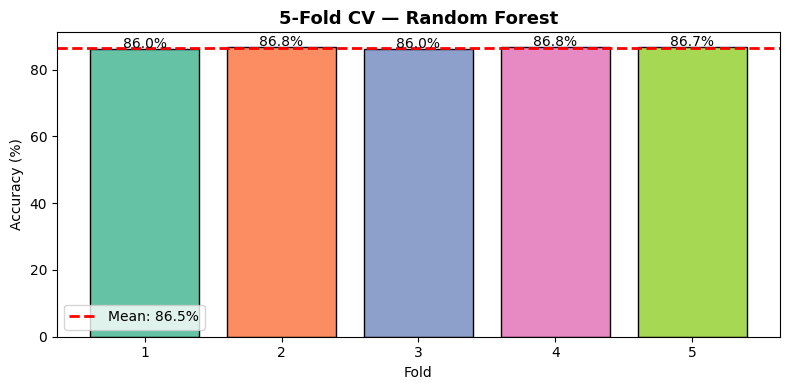

✅ Saved: rf_kfold_cv.png


In [12]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
cv_scores = cross_val_score(rf_model, X_train_sc, y_train,
                             cv=skf, scoring="accuracy", n_jobs=-1)

print(f"=== 5-Fold Cross-Validation: Random Forest ===")
for i, s in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {s*100:.2f}%")
print(f"\n  Mean  : {cv_scores.mean()*100:.2f}%")
print(f"  Std   : {cv_scores.std()*100:.2f}%")
print(f"  95% CI: [{(cv_scores.mean()-2*cv_scores.std())*100:.2f}%,"
      f" {(cv_scores.mean()+2*cv_scores.std())*100:.2f}%]")

plt.figure(figsize=(8, 4))
bars = plt.bar(range(1, 6), cv_scores * 100,
               color=sns.color_palette("Set2", 5), edgecolor="black")
plt.axhline(cv_scores.mean() * 100, color="red", lw=2,
            linestyle="--", label=f"Mean: {cv_scores.mean()*100:.1f}%")
for bar, val in zip(bars, cv_scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
             f"{val*100:.1f}%", ha="center", fontsize=10)
plt.xlabel("Fold"); plt.ylabel("Accuracy (%)")
plt.title("5-Fold CV — Random Forest", fontsize=13, fontweight="bold")
plt.legend(); plt.tight_layout()
plt.savefig("rf_kfold_cv.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: rf_kfold_cv.png")

In [13]:
# Compute class weights for weighted loss
class_weights_np = compute_class_weight('balanced',
                                         classes=np.unique(y_train_sm),
                                         y=y_train_sm)
class_weights_tensor = torch.tensor(class_weights_np, dtype=torch.float32).to(DEVICE)
print("Class weights:", dict(zip(le.classes_, class_weights_np.round(3))))


class AudioDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):        return len(self.y)
    def __getitem__(self, i): return self.X[i], self.y[i]


class ChannelAttention(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        self.se = nn.Sequential(
            nn.AdaptiveAvgPool1d(1), nn.Flatten(),
            nn.Linear(channels, channels // reduction), nn.GELU(),
            nn.Linear(channels // reduction, channels), nn.Sigmoid()
        )
    def forward(self, x):
        return x * self.se(x).unsqueeze(-1)


class ResidualBlock(nn.Module):
    def __init__(self, channels, kernel_size=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels), nn.GELU(),
            nn.Conv1d(channels, channels, kernel_size, padding=kernel_size//2),
            nn.BatchNorm1d(channels),
        )
        self.act = nn.GELU()
    def forward(self, x):
        return self.act(x + self.block(x))


class RespiratoryNet(nn.Module):
    """
    Deeper CNN with:
      - 4 progressive conv stages (32→64→128→256→512)
      - Residual blocks in every stage
      - Channel Attention (SE) after final stage
      - Temperature scaling to reduce overconfidence
      - High dropout (0.5) to prevent overfitting on small dataset
    """
    def __init__(self, num_classes, dropout=0.5):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=7, padding=3),
            nn.BatchNorm1d(32), nn.GELU(), nn.MaxPool1d(2)
        )
        self.stage1 = nn.Sequential(
            nn.Conv1d(32, 64, kernel_size=5, padding=2),
            nn.BatchNorm1d(64), nn.GELU(), nn.MaxPool1d(2),
            ResidualBlock(64), ResidualBlock(64)
        )
        self.stage2 = nn.Sequential(
            nn.Conv1d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm1d(128), nn.GELU(), nn.MaxPool1d(2),
            ResidualBlock(128), ResidualBlock(128)
        )
        self.stage3 = nn.Sequential(
            nn.Conv1d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm1d(256), nn.GELU(),
            ResidualBlock(256)
        )
        self.stage4 = nn.Sequential(
            nn.Conv1d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm1d(512), nn.GELU(),
            ResidualBlock(512)
        )
        self.attn = ChannelAttention(512, reduction=8)
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.clf  = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 512), nn.GELU(), nn.Dropout(dropout),
            nn.Linear(512, 256), nn.GELU(), nn.Dropout(dropout / 2),
            nn.Linear(256, 128), nn.GELU(), nn.Dropout(dropout / 4),
            nn.Linear(128, num_classes)
        )
        self.temperature = nn.Parameter(torch.ones(1) * 1.5)

    def forward(self, x):
        x = self.stem(x)
        x = self.stage1(x)
        x = self.stage2(x)
        x = self.stage3(x)
        x = self.stage4(x)
        x = self.attn(x)
        x = self.pool(x)
        return self.clf(x) / self.temperature


NUM_CLASSES = len(le.classes_)
model = RespiratoryNet(NUM_CLASSES).to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal parameters: {total_params:,}")

Class weights: {np.str_('COPD'): np.float64(1.0), np.str_('Healthy'): np.float64(1.0), np.str_('Other'): np.float64(1.0), np.str_('Pneumonia'): np.float64(1.0), np.str_('URTI'): np.float64(1.0)}

Total parameters: 3,241,926


In [14]:
train_ds = AudioDataset(X_train,   y_train_sm)
val_ds   = AudioDataset(X_val_sc,  y_val)
test_ds  = AudioDataset(X_test_sc, y_test)

BATCH        = 32
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=2, pin_memory=True)
print(f"Train: {len(train_ds)}  Val: {len(val_ds)}  Test: {len(test_ds)}")

Train: 2775  Val: 138  Test: 138


In [15]:
EPOCHS    = 80
PATIENCE  = 15

criterion = nn.CrossEntropyLoss(weight=class_weights_tensor, label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=5e-4, weight_decay=1e-4)
scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS, eta_min=1e-6)

history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
best_val_loss  = float("inf")
patience_count = 0


def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss = correct = total = 0
    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for Xb, yb in loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            if train: optimizer.zero_grad()
            out  = model(Xb)
            loss = criterion(out, yb)
            if train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), 1.0)
                optimizer.step()
            total_loss += loss.item() * len(yb)
            correct    += (out.argmax(1) == yb).sum().item()
            total      += len(yb)
    return total_loss / total, correct / total


print(f"{'Epoch':>6} | {'T-Loss':>8} {'T-Acc':>7} | {'V-Loss':>8} {'V-Acc':>7} | {'Status':>12}")
print("-" * 62)

for epoch in range(1, EPOCHS + 1):
    tl, ta = run_epoch(train_loader, train=True)
    vl, va = run_epoch(val_loader,   train=False)
    scheduler.step()

    history["train_loss"].append(tl); history["val_loss"].append(vl)
    history["train_acc"].append(ta);  history["val_acc"].append(va)

    if vl < best_val_loss:
        best_val_loss  = vl
        patience_count = 0
        torch.save(model.state_dict(), "best_model.pt")
        status = "✅ saved"
    else:
        patience_count += 1
        status = f"⏳ {patience_count}/{PATIENCE}"

    if epoch % 10 == 0 or epoch == 1:
        print(f"{epoch:6d} | {tl:8.4f} {ta*100:6.2f}% | {vl:8.4f} {va*100:6.2f}% | {status}")

    if patience_count >= PATIENCE:
        print(f"\n🛑 Early stopping at epoch {epoch}")
        break

print(f"\n✅ Best Val Loss: {best_val_loss:.4f}")

 Epoch |   T-Loss   T-Acc |   V-Loss   V-Acc |       Status
--------------------------------------------------------------
     1 |   1.1197  58.38% |   0.8929  84.78% | ✅ saved
    10 |   0.4072  99.60% |   0.7962  86.23% | ⏳ 2/15
    20 |   0.4057  99.50% |   0.7591  87.68% | ⏳ 2/15
    30 |   0.3938 100.00% |   0.6959  88.41% | ⏳ 4/15
    40 |   0.3959  99.89% |   0.6529  89.13% | ⏳ 6/15
    50 |   0.3928 100.00% |   0.6789  90.58% | ⏳ 9/15

🛑 Early stopping at epoch 56

✅ Best Val Loss: 0.6447


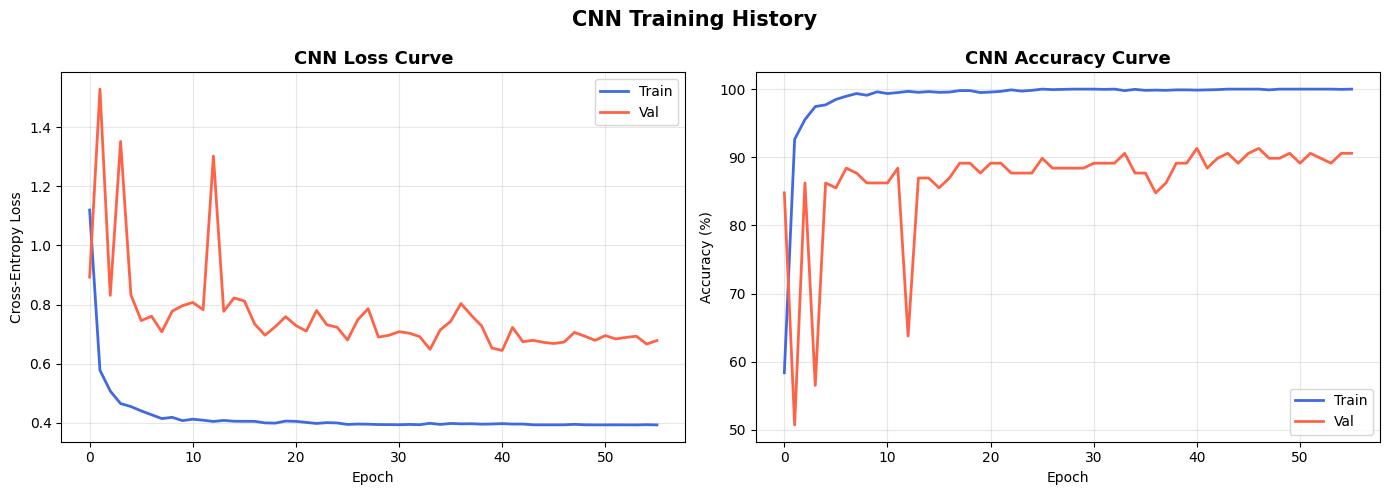

✅ Saved: cnn_training_curves.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history["train_loss"], label="Train", lw=2, color="royalblue")
axes[0].plot(history["val_loss"],   label="Val",   lw=2, color="tomato")
axes[0].set_title("CNN Loss Curve", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Cross-Entropy Loss")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot([a*100 for a in history["train_acc"]], label="Train", lw=2, color="royalblue")
axes[1].plot([a*100 for a in history["val_acc"]],   label="Val",   lw=2, color="tomato")
axes[1].set_title("CNN Accuracy Curve", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy (%)")
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.suptitle("CNN Training History", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("cnn_training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: cnn_training_curves.png")

   CNN + Attention — TEST SET RESULTS
              precision    recall  f1-score   support

        COPD       0.95      0.98      0.97       119
     Healthy       0.33      0.20      0.25         5
       Other       0.67      0.40      0.50         5
   Pneumonia       0.25      0.33      0.29         6
        URTI       1.00      0.33      0.50         3

    accuracy                           0.89       138
   macro avg       0.64      0.45      0.50       138
weighted avg       0.89      0.89      0.88       138



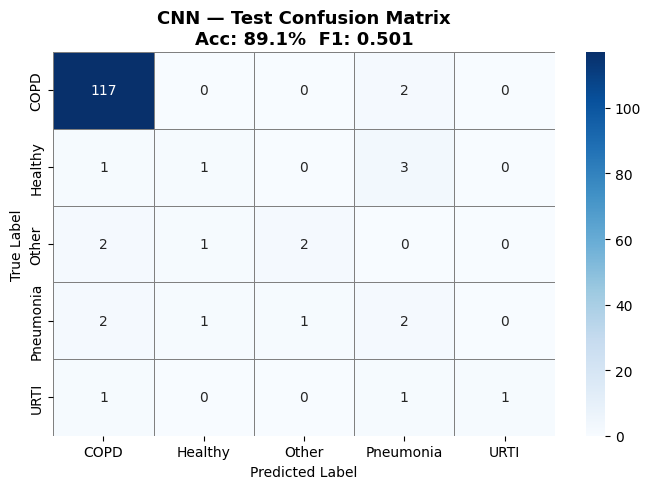

✅ Saved: cnn_confusion_matrix.png


In [17]:
model.load_state_dict(torch.load("best_model.pt", map_location=DEVICE))
model.eval()

cnn_preds, cnn_true, cnn_probs = [], [], []
with torch.no_grad():
    for Xb, yb in test_loader:
        logits = model(Xb.to(DEVICE))
        probs  = torch.softmax(logits, dim=1).cpu().numpy()
        preds  = logits.argmax(1).cpu().numpy()
        cnn_probs.extend(probs)
        cnn_preds.extend(preds)
        cnn_true.extend(yb.numpy())

cnn_preds = np.array(cnn_preds)
cnn_true  = np.array(cnn_true)
cnn_probs = np.array(cnn_probs)

cnn_test_acc = accuracy_score(cnn_true, cnn_preds)
cnn_test_f1  = f1_score(cnn_true, cnn_preds, average="macro")

print("=" * 55)
print("   CNN + Attention — TEST SET RESULTS")
print("=" * 55)
print(classification_report(cnn_true, cnn_preds, target_names=le.classes_))

cm_cnn = confusion_matrix(cnn_true, cnn_preds)
plt.figure(figsize=(7, 5))
sns.heatmap(cm_cnn, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_,
            linewidths=0.5, linecolor="gray")
plt.title(f"CNN — Test Confusion Matrix\nAcc: {cnn_test_acc*100:.1f}%  F1: {cnn_test_f1:.3f}",
          fontsize=13, fontweight="bold")
plt.ylabel("True Label"); plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("cnn_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: cnn_confusion_matrix.png")

       MODEL COMPARISON — TEST SET
Metric                      Random Forest CNN + Attention
-------------------------------------------------------
Accuracy (%)                        92.03           89.13
F1 Score (Macro)                   0.5413          0.5005
Better Accuracy                                      RF ✅
Better F1                                            RF ✅


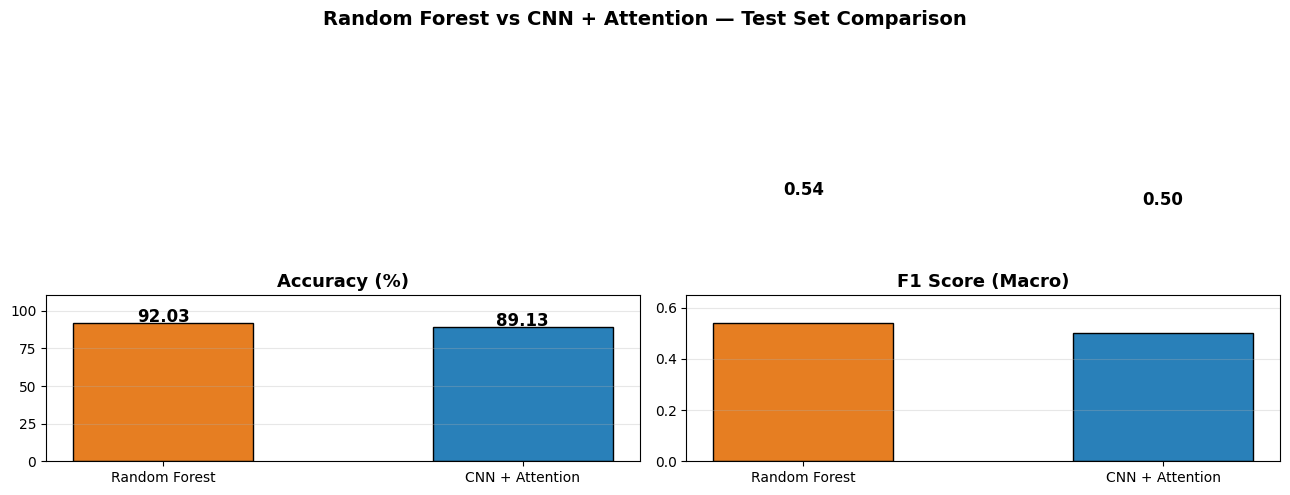

✅ Saved: model_comparison.png


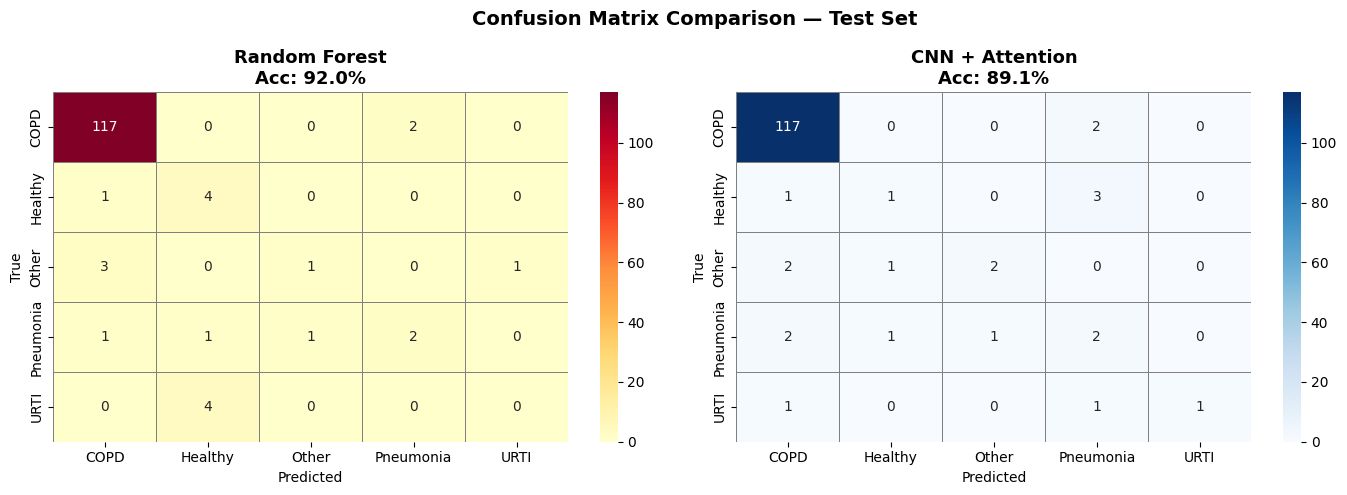

✅ Saved: confusion_matrix_comparison.png


In [18]:
# RF test set evaluation
rf_test_preds = rf_model.predict(X_test_sc)
rf_test_probs = rf_model.predict_proba(X_test_sc)
rf_test_acc   = accuracy_score(y_test, rf_test_preds)
rf_test_f1    = f1_score(y_test, rf_test_preds, average="macro")

print("=" * 55)
print("       MODEL COMPARISON — TEST SET")
print("=" * 55)
print(f"{'Metric':<25} {'Random Forest':>15} {'CNN + Attention':>15}")
print("-" * 55)
print(f"{'Accuracy (%)':<25} {rf_test_acc*100:>15.2f} {cnn_test_acc*100:>15.2f}")
print(f"{'F1 Score (Macro)':<25} {rf_test_f1:>15.4f} {cnn_test_f1:>15.4f}")
winner_acc = "CNN ✅" if cnn_test_acc > rf_test_acc else "RF ✅"
winner_f1  = "CNN ✅" if cnn_test_f1 > rf_test_f1  else "RF ✅"
print(f"{'Better Accuracy':<25} {winner_acc:>31}")
print(f"{'Better F1':<25} {winner_f1:>31}")

# ── Side-by-side bar chart ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

metrics = ["Accuracy (%)", "F1 Score (Macro)"]
rf_vals  = [rf_test_acc * 100,  rf_test_f1]
cnn_vals = [cnn_test_acc * 100, cnn_test_f1]

for ax, metric, rf_v, cnn_v in zip(axes, metrics, rf_vals, cnn_vals):
    bars = ax.bar(["Random Forest", "CNN + Attention"],
                  [rf_v, cnn_v],
                  color=["#e67e22", "#2980b9"],
                  edgecolor="black", width=0.5)
    for bar, val in zip(bars, [rf_v, cnn_v]):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.5,
                f"{val:.2f}", ha="center", fontsize=12, fontweight="bold")
    ax.set_title(metric, fontsize=13, fontweight="bold")
    ax.set_ylim(0, max(rf_v, cnn_v) * 1.2)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Random Forest vs CNN + Attention — Test Set Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: model_comparison.png")

# ── Side-by-side confusion matrices ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, cm, title, cmap in zip(
        axes,
        [cm_rf, cm_cnn],
        [f"Random Forest\nAcc: {rf_test_acc*100:.1f}%",
         f"CNN + Attention\nAcc: {cnn_test_acc*100:.1f}%"],
        ["YlOrRd", "Blues"]):
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=ax,
                xticklabels=le.classes_, yticklabels=le.classes_,
                linewidths=0.5, linecolor="gray")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.set_ylabel("True"); ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrix Comparison — Test Set", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: confusion_matrix_comparison.png")

Computing SHAP values on Random Forest...
Type of shap_vals : <class 'numpy.ndarray'>
SHAP values shape used for plot: (80, 414)
X_shap_eval shape              : (80, 414)


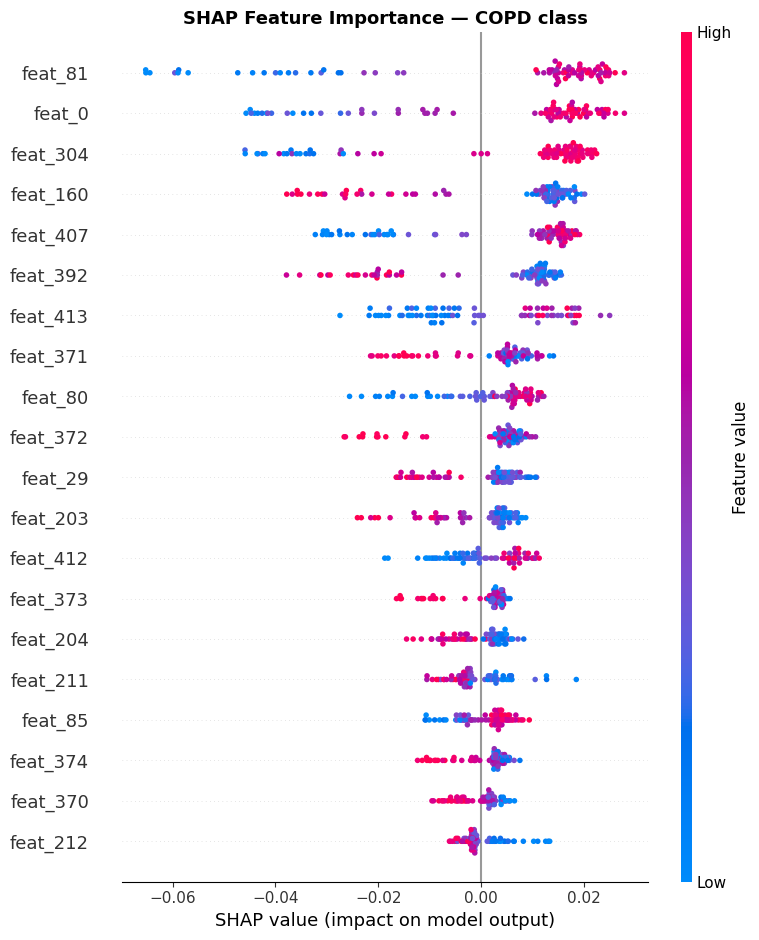

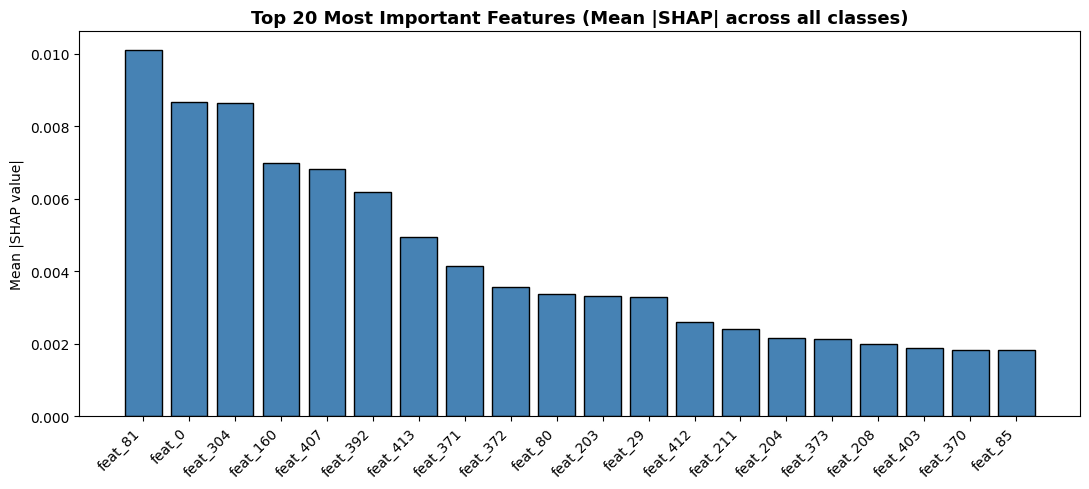

In [19]:
print("Computing SHAP values on Random Forest...")

# rf_model = baselines["Random Forest"]

# Use a small subset for speed
X_shap_bg   = X_train[:100]       # background (used by explainer)
X_shap_eval = X_val_sc[:80]       # samples to explain

explainer = shap.TreeExplainer(rf_model, data=X_shap_bg, feature_perturbation="interventional")
shap_vals = explainer.shap_values(X_shap_eval)

print(f"Type of shap_vals : {type(shap_vals)}")

# --------------------------------------------------------------------------
# SHAP returns different shapes depending on version:
#   Old API → list of arrays, one per class  → shape (80, n_features) each
#   New API → single 3D array                → shape (80, n_features, n_classes)
# Handle both:
# --------------------------------------------------------------------------
if isinstance(shap_vals, list):
    # Old API → list[class_idx] → (n_samples, n_features)
    copd_idx   = list(le.classes_).index("COPD")
    sv_copd    = shap_vals[copd_idx]                      # (80, n_features)
    mean_shap  = np.mean([np.abs(sv).mean(axis=0) for sv in shap_vals], axis=0)
else:
    # New API → single array (n_samples, n_features, n_classes)
    copd_idx   = list(le.classes_).index("COPD")
    sv_copd    = shap_vals[:, :, copd_idx]                # (80, n_features)
    mean_shap  = np.abs(shap_vals).mean(axis=(0, 2))      # mean over samples & classes

print(f"SHAP values shape used for plot: {sv_copd.shape}")
print(f"X_shap_eval shape              : {X_shap_eval.shape}")

feat_names = [f"feat_{i}" for i in range(X_shap_eval.shape[1])]

# ── Summary beeswarm plot ─────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(sv_copd, X_shap_eval,
                  max_display=20,
                  show=False,
                  feature_names=feat_names)
plt.title("SHAP Feature Importance — COPD class", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.show()

# ── Bar plot — top 20 features by mean |SHAP| across all classes ──────
top20_idx = np.argsort(mean_shap)[-20:][::-1]

plt.figure(figsize=(11, 5))
plt.bar(range(20), mean_shap[top20_idx], color="steelblue", edgecolor="black")
plt.xticks(range(20), [feat_names[i] for i in top20_idx], rotation=45, ha="right")
plt.title("Top 20 Most Important Features (Mean |SHAP| across all classes)",
          fontsize=13, fontweight="bold")
plt.ylabel("Mean |SHAP value|")
plt.tight_layout(); plt.show()

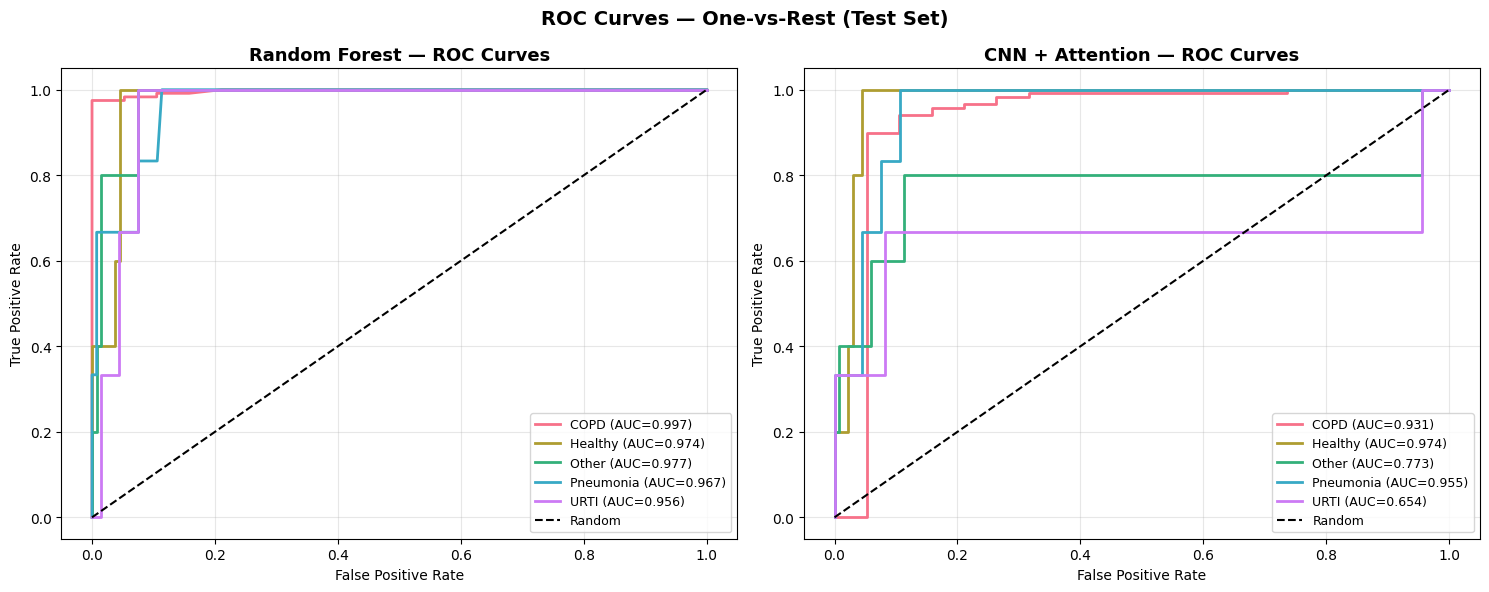

✅ Saved: roc_curves_comparison.png


In [20]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(cnn_true, classes=range(NUM_CLASSES))
colors     = sns.color_palette("husl", NUM_CLASSES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

for ax, probs_arr, title in zip(
        axes,
        [rf_test_probs, cnn_probs],
        ["Random Forest — ROC Curves", "CNN + Attention — ROC Curves"]):
    for i, (cls, color) in enumerate(zip(le.classes_, colors)):
        fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs_arr[:, i])
        roc_auc_val = auc(fpr, tpr)
        ax.plot(fpr, tpr, lw=2, color=color, label=f"{cls} (AUC={roc_auc_val:.3f})")
    ax.plot([0,1],[0,1],"k--", lw=1.5, label="Random")
    ax.set_xlabel("False Positive Rate"); ax.set_ylabel("True Positive Rate")
    ax.set_title(title, fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=9); ax.grid(alpha=0.3)

plt.suptitle("ROC Curves — One-vs-Rest (Test Set)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("roc_curves_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Saved: roc_curves_comparison.png")

File: 161_1b1_Pl_sc_Meditron.wav
True Label: Other

  🫁  PREDICTION  : Healthy
  📊  CONFIDENCE  : 92.8%
  Healthy          92.8%  ███████████████████████████
  Other             1.9%  
  URTI              1.8%  
  COPD              1.8%  
  Pneumonia         1.8%  


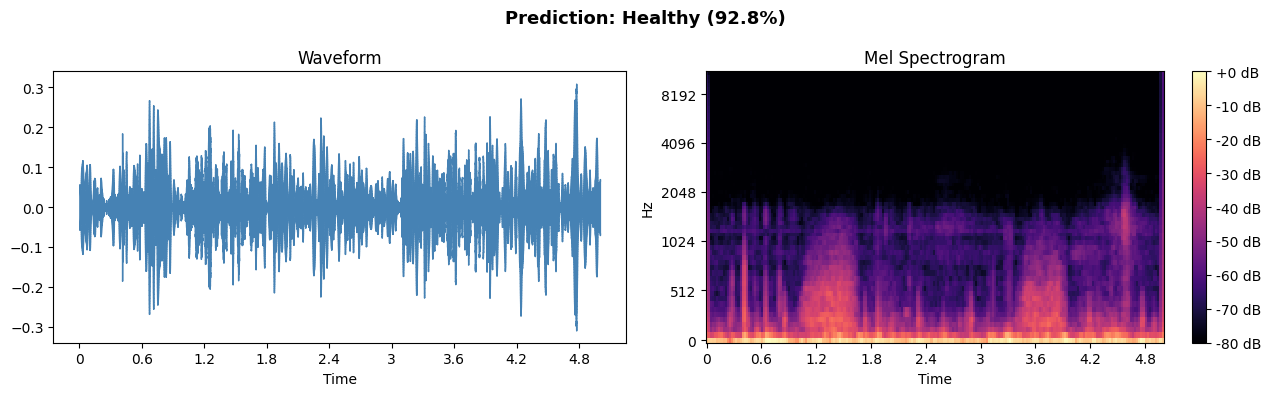

(np.str_('Healthy'), np.float32(92.78274))

In [21]:
def predict_disease(wav_path: str):
    """Full pipeline: load → denoise → extract → scale → predict."""
    y_audio  = load_and_clean(wav_path)
    feat     = extract_features(y_audio)
    feat_sc  = scaler.transform([feat]).astype(np.float32)
    tensor   = torch.tensor(feat_sc).unsqueeze(1).to(DEVICE)

    model.eval()
    with torch.no_grad():
        probs = torch.softmax(model(tensor), dim=1).cpu().numpy()[0]

    pred       = le.classes_[probs.argmax()]
    confidence = probs.max() * 100

    # Pretty print
    print(f"\n{'='*45}")
    print(f"  🫁  PREDICTION  : {pred}")
    print(f"  📊  CONFIDENCE  : {confidence:.1f}%")
    print(f"{'='*45}")
    for cls, p in sorted(zip(le.classes_, probs), key=lambda x: -x[1]):
        bar = "█" * int(p * 30)
        print(f"  {cls:15s} {p*100:5.1f}%  {bar}")

    # Visualise the audio
    y_s, _ = librosa.load(wav_path, sr=SR, duration=DURATION)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    librosa.display.waveshow(y_s, sr=SR, ax=axes[0], color="steelblue")
    axes[0].set_title("Waveform")
    mel_db = librosa.power_to_db(librosa.feature.melspectrogram(y=y_s, sr=SR, n_mels=N_MELS), ref=np.max)
    img = librosa.display.specshow(mel_db, sr=SR, x_axis="time", y_axis="mel", ax=axes[1])
    fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
    axes[1].set_title("Mel Spectrogram")
    plt.suptitle(f"Prediction: {pred} ({confidence:.1f}%)", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()

    return pred, confidence


# Test on first file
test_file  = os.path.join(AUDIO_DIR, wav_files[0])
true_label = pid2label.get(int(wav_files[0].split("_")[0]), "Unknown")
print(f"File: {wav_files[0]}\nTrue Label: {true_label}")
predict_disease(test_file)

In [22]:
from google.colab import files

images = [
    "cnn_training_curves.png",
    "cnn_confusion_matrix.png",
    "rf_confusion_matrix.png",
    "rf_kfold_cv.png",
    "model_comparison.png",
    "confusion_matrix_comparison.png",
    "roc_curves_comparison.png",
]

print("Downloading all report images...\n")
for img in images:
    if os.path.exists(img):
        files.download(img)
        print(f"✅ Downloaded: {img}")
    else:
        print(f"❌ Not found (did you run that cell?): {img}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: cnn_training_curves.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✅ Downloaded: confusion_matrix_comparison.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Downloaded: roc_curves_comparison.png


📁 Click 'Choose Files' — supports .wav or .mp3



Saving CoughAudio.mp4 to CoughAudio.mp4

✅ Uploaded: CoughAudio.mp4

  🏥  PREDICTION  : COPD
  📊  CONFIDENCE  : 92.6%
  🎲  UNCERTAINTY : 22.9%  (higher = model less sure)

  ℹ️   Chronic Obstructive Pulmonary Disease — persistent blocked airflow

  ⚠️  IMPORTANT LIMITATIONS:
  • Model trained on STETHOSCOPE recordings, not microphone audio
  • Your upload may sound very different from training data
  • If uncertainty > 60%, the prediction is likely unreliable
  • This is NOT a medical diagnosis — consult a doctor

  Class Probabilities:
  COPD             92.6%  ████████████████████████████████░░░ ← predicted
  Other             1.9%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Healthy           1.9%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  URTI              1.9%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░
  Pneumonia         1.8%  ░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░


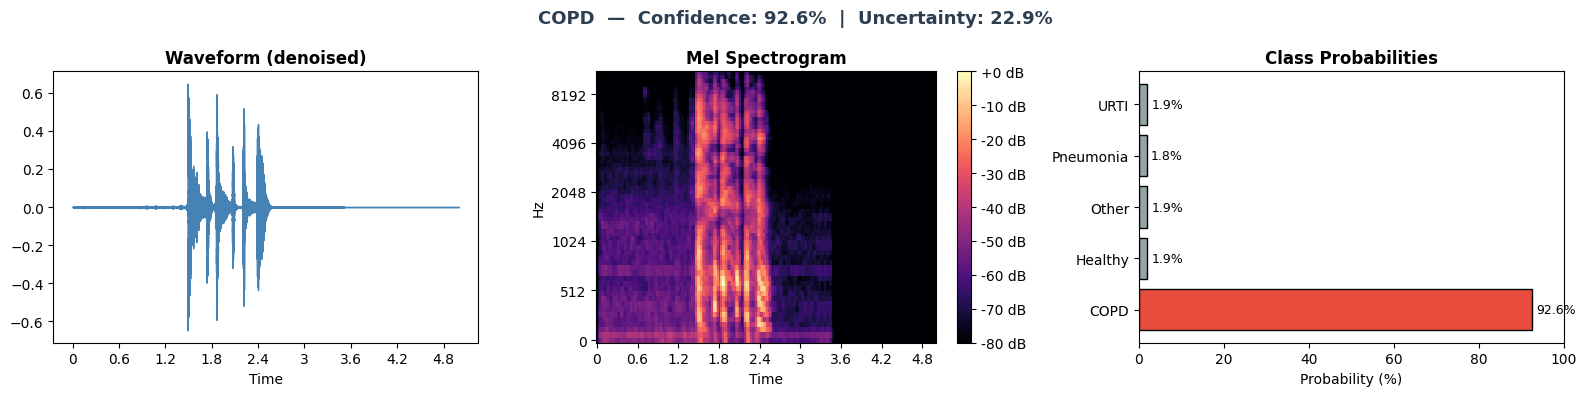

In [23]:
from google.colab import files

# Confidence threshold — if model isn't sure enough, say "uncertain"
CONFIDENCE_THRESHOLD = 40.0  # percent

DESCRIPTIONS = {
    "COPD":     "Chronic Obstructive Pulmonary Disease — persistent blocked airflow",
    "Healthy":  "No respiratory disease detected",
    "URTI":     "Upper Respiratory Tract Infection — e.g. common cold",
    "Pneumonia":"Lung infection causing fluid buildup in air sacs",
    "Other":    "Bronchiectasis / Bronchiolitis / Asthma / LRTI",
}

def upload_and_predict():
    print("📁 Click 'Choose Files' — supports .wav or .mp3\n")
    uploaded = files.upload()
    if not uploaded:
        print("❌ No file uploaded."); return

    for filename, file_bytes in uploaded.items():
        print(f"\n✅ Uploaded: {filename}")

        save_path = f"/tmp/{filename}"
        with open(save_path, "wb") as f:
            f.write(file_bytes)

        try:
            y_audio, _ = librosa.load(save_path, sr=SR, duration=DURATION)
        except Exception as e:
            print(f"❌ Could not load: {e}"); return

        # Pad / trim
        if len(y_audio) < FIXED_LEN:
            y_audio = np.pad(y_audio, (0, FIXED_LEN - len(y_audio)))
        else:
            y_audio = y_audio[:FIXED_LEN]

        # Denoise
        noise_sample = y_audio[:int(SR * 0.5)]
        y_clean = nr.reduce_noise(y=y_audio, y_noise=noise_sample, sr=SR, prop_decrease=0.8)

        # Feature extraction → scale → predict
        feat    = extract_features(y_clean)
        feat_sc = scaler.transform([feat]).astype(np.float32)
        tensor  = torch.tensor(feat_sc).unsqueeze(1).to(DEVICE)

        model.eval()
        with torch.no_grad():
            logits = model(tensor)
            probs  = torch.softmax(logits, dim=1).cpu().numpy()[0]

        pred       = le.classes_[probs.argmax()]
        confidence = probs.max() * 100

        # Entropy — measures how "spread out" the probabilities are
        # High entropy = model is confused between multiple classes
        entropy = -np.sum(probs * np.log(probs + 1e-9))
        max_entropy = np.log(len(le.classes_))  # worst case
        uncertainty_pct = (entropy / max_entropy) * 100

        # ── Print results ──────────────────────────────────────────────────
        print(f"\n{'='*55}")
        if confidence < CONFIDENCE_THRESHOLD:
            print(f"  ⚠️   PREDICTION : UNCERTAIN (low confidence)")
            print(f"  🏥  Best guess  : {pred}")
        else:
            print(f"  🏥  PREDICTION  : {pred}")

        print(f"  📊  CONFIDENCE  : {confidence:.1f}%")
        print(f"  🎲  UNCERTAINTY : {uncertainty_pct:.1f}%  (higher = model less sure)")
        print(f"{'='*55}")
        print(f"\n  ℹ️   {DESCRIPTIONS.get(pred, '')}")

        # Domain mismatch warning
        print(f"\n  ⚠️  IMPORTANT LIMITATIONS:")
        print(f"  • Model trained on STETHOSCOPE recordings, not microphone audio")
        print(f"  • Your upload may sound very different from training data")
        print(f"  • If uncertainty > 60%, the prediction is likely unreliable")
        print(f"  • This is NOT a medical diagnosis — consult a doctor\n")

        print("  Class Probabilities:")
        for cls, p in sorted(zip(le.classes_, probs), key=lambda x: -x[1]):
            bar   = "█" * int(p * 35)
            empty = "░" * (35 - int(p * 35))
            flag  = " ← predicted" if cls == pred else ""
            print(f"  {cls:15s} {p*100:5.1f}%  {bar}{empty}{flag}")

        # ── Visualise ──────────────────────────────────────────────────────
        fig, axes = plt.subplots(1, 3, figsize=(16, 4))

        librosa.display.waveshow(y_clean, sr=SR, ax=axes[0], color="steelblue")
        axes[0].set_title("Waveform (denoised)", fontweight="bold")

        mel_db = librosa.power_to_db(
            librosa.feature.melspectrogram(y=y_clean, sr=SR, n_mels=N_MELS), ref=np.max)
        img = librosa.display.specshow(mel_db, sr=SR, hop_length=HOP_LENGTH,
                                       x_axis="time", y_axis="mel", ax=axes[1])
        fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
        axes[1].set_title("Mel Spectrogram", fontweight="bold")

        colors_bar = ["#e74c3c" if c == pred else "#95a5a6" for c in le.classes_]
        axes[2].barh(le.classes_, probs * 100, color=colors_bar, edgecolor="black")
        axes[2].set_xlabel("Probability (%)")
        axes[2].set_title("Class Probabilities", fontweight="bold")
        axes[2].set_xlim(0, 100)
        for i, p in enumerate(probs):
            axes[2].text(p * 100 + 1, i, f"{p*100:.1f}%", va="center", fontsize=9)

        title_color = "#e74c3c" if confidence < CONFIDENCE_THRESHOLD else (
                      "green" if pred == "Healthy" else "#2c3e50")
        plt.suptitle(
            f"{'⚠️ UNCERTAIN' if confidence < CONFIDENCE_THRESHOLD else pred}"
            f"  —  Confidence: {confidence:.1f}%  |  Uncertainty: {uncertainty_pct:.1f}%",
            fontsize=13, fontweight="bold", color=title_color)
        plt.tight_layout(); plt.show()


upload_and_predict()